In [1]:
import pulp
import scipy.optimize as opt

# Objective function coefficients (negated because linprog minimizes)
# Maximize 20G + 30W is equivalent to Minimize -20G - 30W
c = [-20, -30]

# Inequality constraints matrix (left-hand side)
A_ub = [
    [2, 3],  # Machine time: 2G + 3W <= 12
    [1, 1]   # Labor: G + W <= 5
]

# Inequality constraints vector (right-hand side)
b_ub = [12, 5]

# Bounds for variables (G >= 0, W >= 0)
x0_bounds = (0, None)
x1_bounds = (0, None)
bounds = [x0_bounds, x1_bounds]

# Solve the linear programming problem
res = opt.linprog(c, A_ub=A_ub, b_ub=b_ub, bounds=bounds, method='highs')

# Output the results
if res.success:
    print(f"Optimal Solution Found:")
    print(f"Gadgets (G) = {res.x[0]:.2f}")
    print(f"Widgets (W) = {res.x[1]:.2f}")
    # The minimum value is negated to get the maximum profit
    print(f"Max Profit = {-res.fun:.2f}")
else:
    print("No solution found.")


Optimal Solution Found:
Gadgets (G) = 0.00
Widgets (W) = 4.00
Max Profit = 120.00


In [2]:
import pulp

# 1. Initialize the Integer Linear Programming (ILP) problem
prob = pulp.LpProblem("Knapsack_Adventure", pulp.LpMaximize)

# 2. Define our items, including the newly added Sleeping Bag
items = {
    'Tent': {'value': 10, 'weight': 5},
    'Stove': {'value': 40, 'weight': 4},
    'Water Filter': {'value': 30, 'weight': 6},
    'Sleeping Bag': {'value': 50, 'weight': 7}
}

# 3. Define decision variables: x_i in {0, 1}
# In PuLP 4.0+, variables are created directly on the problem object
take_vars = prob.add_variable_dicts("Take", list(items.keys()), cat=pulp.LpBinary)

# 4. Objective Function: Maximize total value
prob += pulp.lpSum(items[item]['value'] * take_vars[item] for item in items), "Total_Value"

# 5. Constraint: Total weight cannot exceed 10 lbs
prob += pulp.lpSum(items[item]['weight'] * take_vars[item] for item in items) <= 10, "Weight_Constraint"

# 6. Solve the problem
res = prob.solve()
# 7. Print the results
print(f"Status: {res.status.name}\n")
print("🎒 Optimal Backpack Contents:")

total_weight = 0
for item in items:
    if take_vars[item].varValue == 1.0:
        print(f" - {item} (Value: {items[item]['value']}, Weight: {items[item]['weight']} lbs)")
        total_weight += items[item]['weight']

print("-" * 30)
print(f"Total Value:  {pulp.value(prob.objective)}")
print(f"Total Weight: {total_weight} lbs")


GLPSOL--GLPK LP/MIP Solver 5.0
Parameter(s) specified in the command line:
 --cpxlp /var/folders/x2/y620t7fd5dl06n7bq9jsb9qw0000gp/T/e127c0b4353745f6b7c479bf9fa3e62e-pulp.lp
 -o /var/folders/x2/y620t7fd5dl06n7bq9jsb9qw0000gp/T/e127c0b4353745f6b7c479bf9fa3e62e-pulp.out
 -w /var/folders/x2/y620t7fd5dl06n7bq9jsb9qw0000gp/T/e127c0b4353745f6b7c479bf9fa3e62e-pulp.sol
Reading problem data from '/var/folders/x2/y620t7fd5dl06n7bq9jsb9qw0000gp/T/e127c0b4353745f6b7c479bf9fa3e62e-pulp.lp'...
1 row, 4 columns, 4 non-zeros
4 integer variables, all of which are binary
13 lines were read
GLPK Integer Optimizer 5.0
1 row, 4 columns, 4 non-zeros
4 integer variables, all of which are binary
Preprocessing...
1 row, 4 columns, 4 non-zeros
4 integer variables, all of which are binary
Scaling...
 A: min|aij| =  4.000e+00  max|aij| =  7.000e+00  ratio =  1.750e+00
Problem data seem to be well scaled
Constructing initial basis...
Size of triangular part is 1
Solving LP relaxation...
GLPK Simplex Optimizer 5.0


Number of runs: 100000
Estimated Pi:   3.13364
Actual Pi:      3.141592653589793
Error:          0.00795



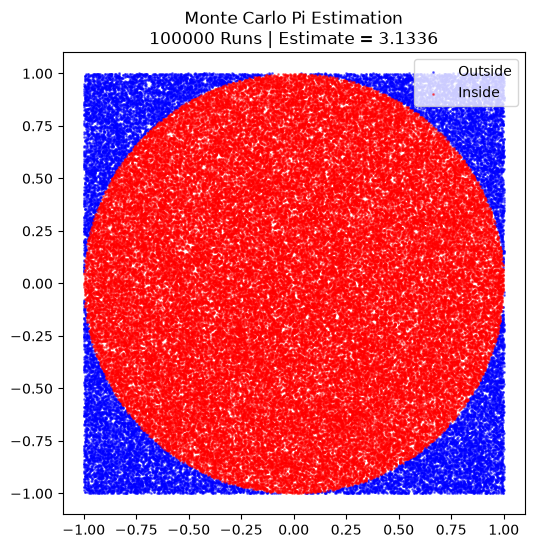

In [7]:
import numpy as np
import matplotlib.pyplot as plt

def estimate_pi_simulation(num_runs):
    """
    Estimates Pi using a Monte Carlo simulation.
    """
    # Generate random x and y coordinates between -1 and 1
    x = np.random.uniform(-1, 1, num_runs)
    y = np.random.uniform(-1, 1, num_runs)
    
    # Calculate the distance from the origin (0,0) for each point
    # If x^2 + y^2 <= 1, the point is inside the unit circle
    is_inside_circle = (x**2 + y**2) <= 1
    
    # Count how many darts landed inside the circle
    inside_count = np.sum(is_inside_circle)
    
    # Pi is approximately 4 * (inside / total)
    pi_estimate = 4 * inside_count / num_runs
    
    print(f"Number of runs: {num_runs}")
    print(f"Estimated Pi:   {pi_estimate}")
    print(f"Actual Pi:      {np.pi}")
    print(f"Error:          {abs(np.pi - pi_estimate):.5f}\n")
    
    # --- Optional: Visualize the simulation ---
    plt.figure(figsize=(6, 6))
    
    # Plot points outside the circle (in blue)
    plt.scatter(x[~is_inside_circle], y[~is_inside_circle], 
                color='blue', s=1, alpha=0.5, label='Outside')
    
    # Plot points inside the circle (in red)
    plt.scatter(x[is_inside_circle], y[is_inside_circle], 
                color='red', s=1, alpha=0.5, label='Inside')
    
    plt.title(f"Monte Carlo Pi Estimation\n{num_runs} Runs | Estimate = {pi_estimate:.4f}")
    plt.legend(loc="upper right")
    plt.xlim(-1.1, 1.1)
    plt.ylim(-1.1, 1.1)
    plt.gca().set_aspect('equal', adjustable='box')
    plt.show()

# ---------------------------------------------------------
# Try changing this number to see how the estimate improves!
# ---------------------------------------------------------
USER_CHOSEN_RUNS = 100000
estimate_pi_simulation(USER_CHOSEN_RUNS)